In [ ]:
Analysis --> Feature Eng. --> Model --> Web app

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns",None)
#set_option() is a pandas function used to change display or behavior settings.
#display.max_columns This option controls how many columns pandas shows when printing a DataFrame.
#Setting it to None means show all columns without any limit.


df = pd.read_csv(r"C:\Users\RABI NARAYAN SWAIN\OneDrive\Desktop\German_Data\german_credit_data.csv")

df
#r = raw string
#It prevents Python from treating \ as special characters
#Very useful for Windows file paths

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [3]:
sns.set_style("whitegrid")
#sns.set_style("whitegrid") changes the background style of plots.

In [4]:
df['Age'].describe()
# It gives all the value of all columns (mean, std, min, max)

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [5]:
df['Risk'].value_counts()
#Counts the number of occurrences of each category in the "Risk" column.


Risk
good    700
bad     300
Name: count, dtype: int64

In [6]:
df.shape
#Data frame all variables and obesevations.

(1000, 11)

In [18]:
df.info()
#Data frame all information.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [7]:
df.describe(include="all").T
#It gives all variables details and (T) is use to transpose. 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df["Job"].unique()
#Gives selected variables unique.

array([2, 1, 3, 0], dtype=int64)

In [9]:
df.isna().sum()
#Counts missing values in each column of the dataset.

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [10]:
df.duplicated().sum()
#Check duplicate in each varianle.

0

In [11]:
df = df.dropna().reset_index(drop=True)
#df.dropna() removes rows that contain missing values (NaN).
#.reset_index() After removing rows, the index numbers become irregular, fixes the index.
#Removes rows with missing values and resets the index numbers of the DataFrame.


In [12]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [13]:
df.columns
#Checks the all variable name.

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [14]:
df.drop(columns = "Unnamed: 0",inplace = True)
#drop variable "Unnamed:0' 

In [15]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


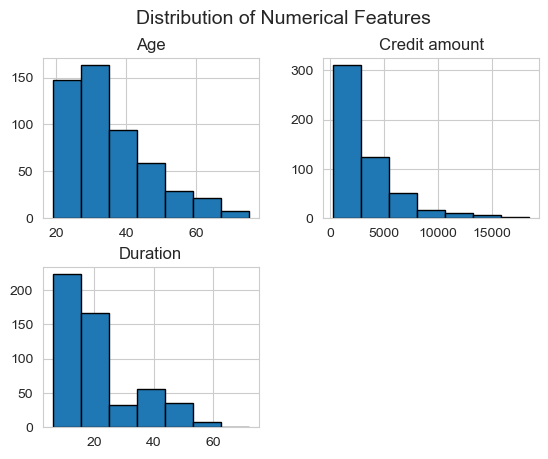

In [34]:
df[["Age","Credit amount","Duration"]].hist(bins=7, edgecolor="black")
#.hist(bins=20, edgecolor="black") This creates histograms for each selected column. Histogram a histogram shows how values are distributed.
#bins = 20, Divides the data into 20 intervals (groups).
#edgecolor = "black" Adds a black border around each bar to make it clearer.

plt.suptitle("Distribution of Numerical Features", fontsize=14)
#plt → Matplotlib plotting module.
#suptitle() → adds a main title above all plots.
#"Distribution of Numerical Features" → title text
#fontsize = 14 → controls the size of the title.
plt.show()

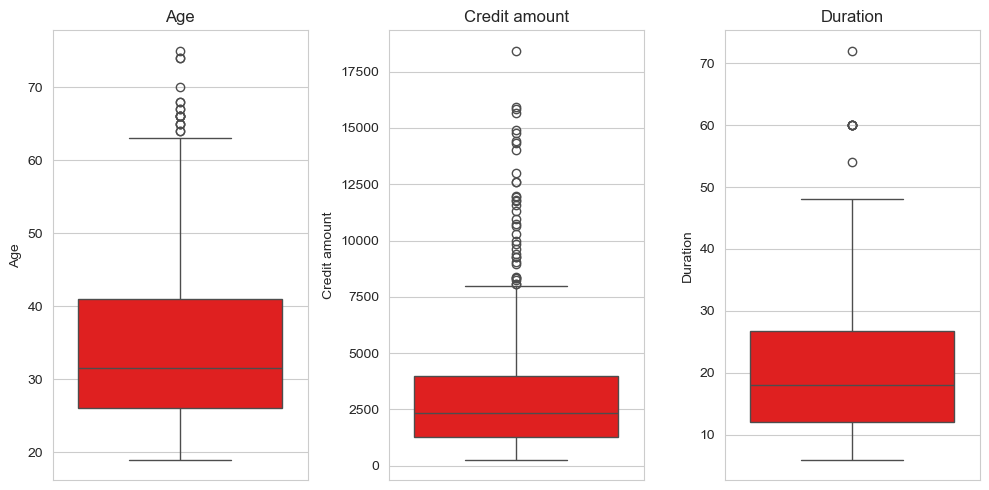

In [17]:
plt.figure(figsize = (10,5))
for i, col in enumerate (["Age","Credit amount","Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y = df[col], color = "red")
    plt.title(col)
plt.tight_layout()
plt.show()

#plt.figure() → creates a new plotting area.
#figsize=(15,5) → sets the width and height of the figure.
#for i, col in enumerate(["Age","Credit amount","Duration"]):
#["Age","Credit amount","Duration"] → list of columns.
#enumerate() → returns index + value.
#plt.subplot(1, 3, i+1)
#subplot(rows, columns, position)
#Here:
#1 → number of rows
#3 → number of columns
#i+1 → plot position
#sns.boxplot(y=df[col], color="yellow")
#Creates a box plot for each column.
#y=df[col] → data from that column
#color="yellow" → box color
#A box plot shows:
#Min | Q1 | Median | Q3 | Max
#plt.title(col)
#Each subplot gets a title:
#Age
#Credit amount
#Duration
#plt.tight_layout() -> This prevents plots from overlapping and improves spacing.


In [19]:
df.query("Duration >= 60")
#query() is a pandas function used to filter data using a condition written like SQL.


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [24]:
categorical_cols = ["Sex","Job", "Housing", "Saving accounts", "Checking account","Purpose",]
                    	

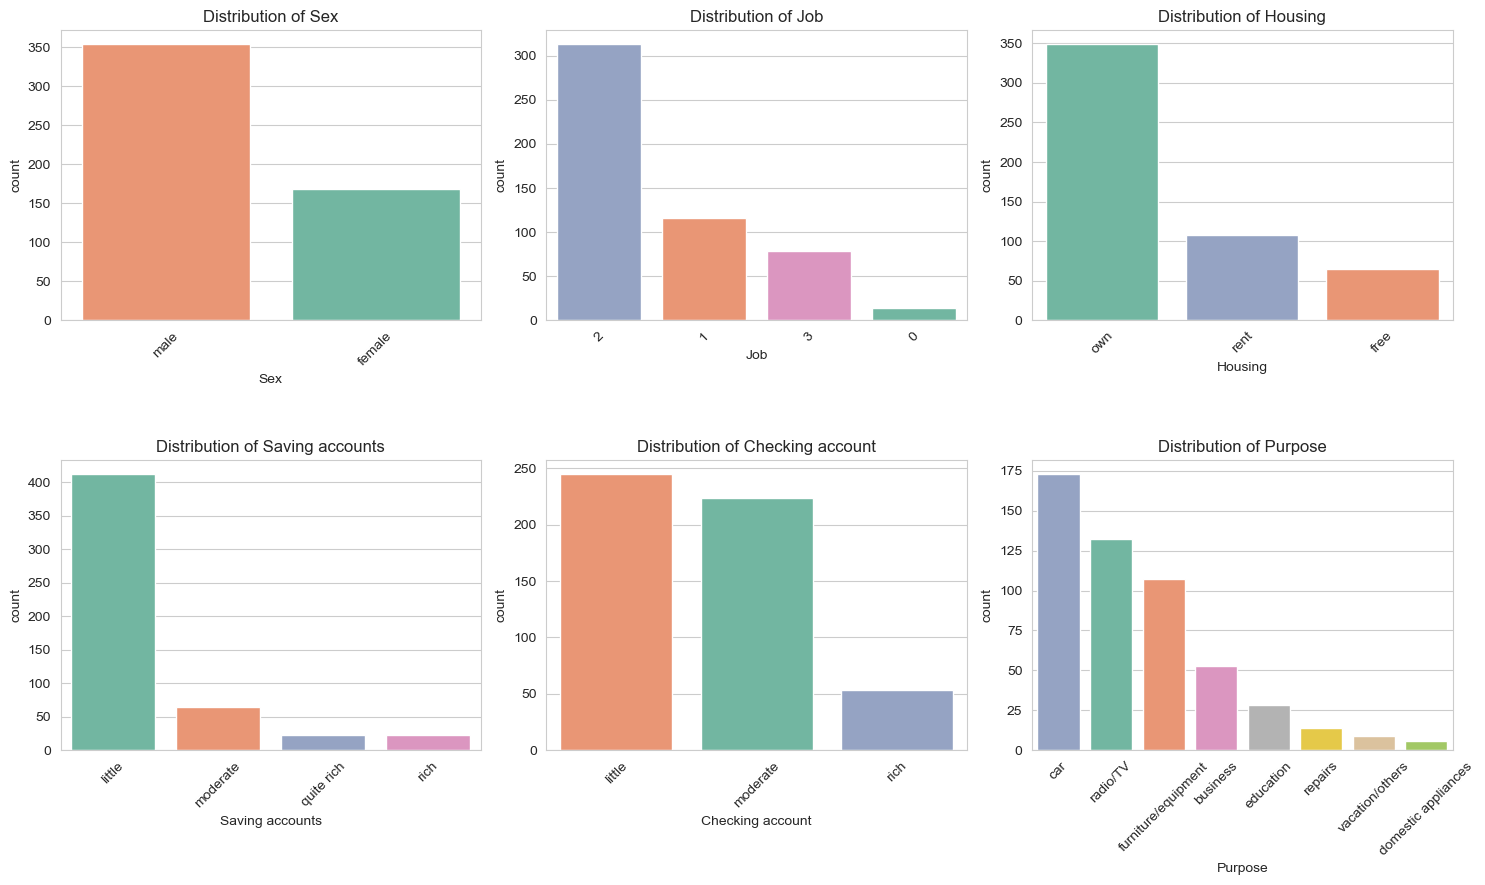

In [26]:
plt.figure(figsize=(15,12))
#Create a large canvas to draw charts.

for i, col in enumerate(categorical_cols):  
#Go through each column in categorical_cols
#enumerate() gives:
#i → index number (0,1,2,3...)
#col → column name
    plt.subplot(3,3,i+1) #You are dividing the big figure into 3 rows and 3 columns, So the page will hold 9 charts, i+1 decides the position of each chart.
    sns.countplot(
        data=df,                  #data=df --> Use the dataframe
        x=col,                    #Put the column categories on x-axis
        hue=col,                  #Color each category differently
        palette="Set2",           #Use a soft color theme
        order=df[col].value_counts().index,     #Show categories from highest count to lowest
        legend=False             #Hide the color legend
    )
    plt.title(f"Distribution of {col}")    #This adds a title.
    
    plt.xticks(rotation=45)   #This rotates labels 45 degrees so they don't overlap.

plt.tight_layout()   #This automatically fixes spacing so charts don't overlap.
plt.show()           #This finally displays all the charts.

In [28]:
corr = df[["Age","Job","Credit amount","Duration"]].corr()
#uses Pandas to calculate the correlation between selected columns in your dataframe.

In [29]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


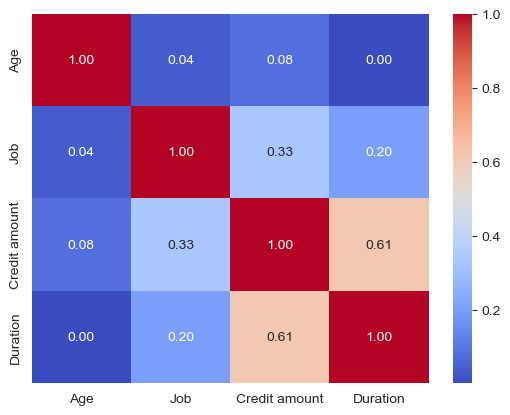

In [31]:
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
#(annot = True): Show the numbers inside each box.
#cmap="coolwarm": This chooses the color theme of the heatmap.
#fmt=".2f": This controls number formatting.Show numbers with 2 decimal places.
plt.show()

In [32]:
df.groupby("Job")["Credit amount"].mean()
#df.groupby("Job")--Group the data based on Job category.
#["Credit amount"] -- Only use the Credit amount column for the calculation.
#.mean() -- This calculates the average (mean).


Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [33]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [35]:
pd.pivot_table(df, values = "Credit amount", index = "Housing", columns = "Purpose")
#pd.pivot_table() --> This function creates a summary table from your dataset.

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


In [36]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


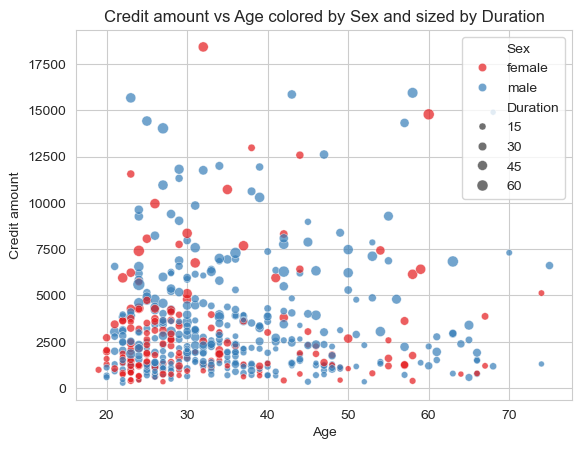

In [43]:
sns.scatterplot(             #sns.scatterplo --> This function creates a scatter plot.
    data=df,                 #Use the dataframe df as the dataset for the plot.
    x="Age",                 #This sets Age on the horizontal axis (X-axis).
    y="Credit amount",       #This sets Credit amount on the vertical axis (Y-axis).
    hue="Sex",               #This colors the dots based on gender.
    size="Duration",         #This changes the size of each dot based on loan duration.
    alpha=0.7,               #This controls transparency of the dots.
    palette="Set1"           #This selects a color theme for the categories.
)

plt.title("Credit amount vs Age colored by Sex and sized by Duration")    #This adds a title to the chart explaining what the visualization shows.
plt.show()

C:\Users\RABI NARAYAN SWAIN\AppData\Local\Temp\ipykernel_7612\2088141427.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")


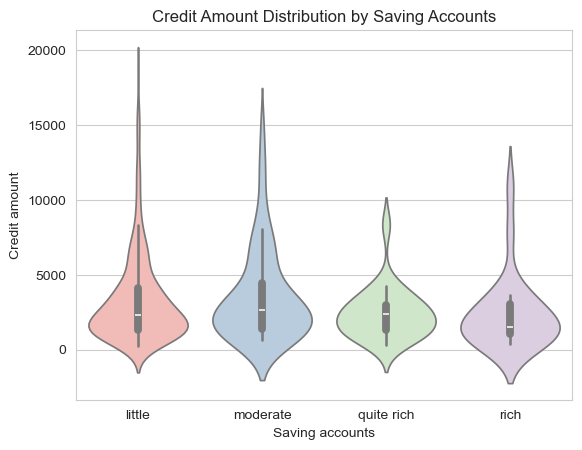

In [50]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()


In [51]:
df["Risk"].value_counts(normalize = True) *100
#df["Risk"] --> This selects the Risk column from the dataframe.
#value_counts() --> This counts how many times each value appears.
#value_counts(normalize=True) --> This converts the counts into proportions (fractions) instead of raw numbers.

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\RABI NARAYAN SWAIN\AppData\Local\Temp\ipykernel_7612\3211350988.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")
C:\Users\RABI NARAYAN SWAIN\AppData\Local\Temp\ipykernel_7612\3211350988.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")
C:\Users\RABI NARAYAN SWAIN\AppData\Local\Temp\ipykernel_7612\3211350988.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")


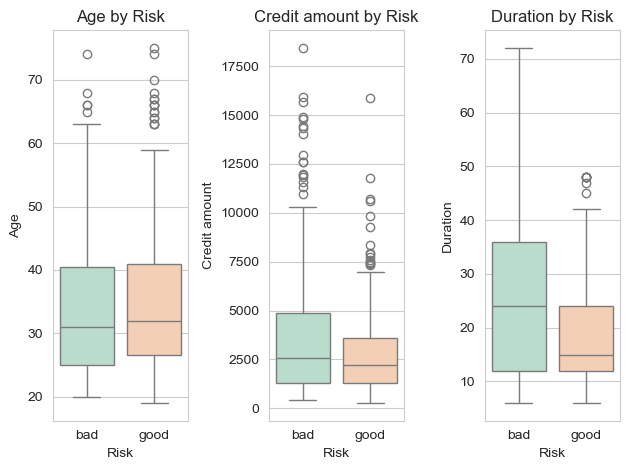

In [56]:

#["Age","Credit Amount","Duration"] --> This is a list in Python.
#enumerate() is a Python function that gives both the index number and the value while looping.
#for loop -->The for loop runs once for each item in the list.

for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3, i+1)          # -->This divides the figure into a grid of plots, This divides the figure into a grid of plots.
    sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2") #A boxplot shows the distribution of numeric data.
    plt.title(f"{col} by Risk")  #This adds a title to each chart.

plt.tight_layout()
plt.show()


In [57]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()


,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [58]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

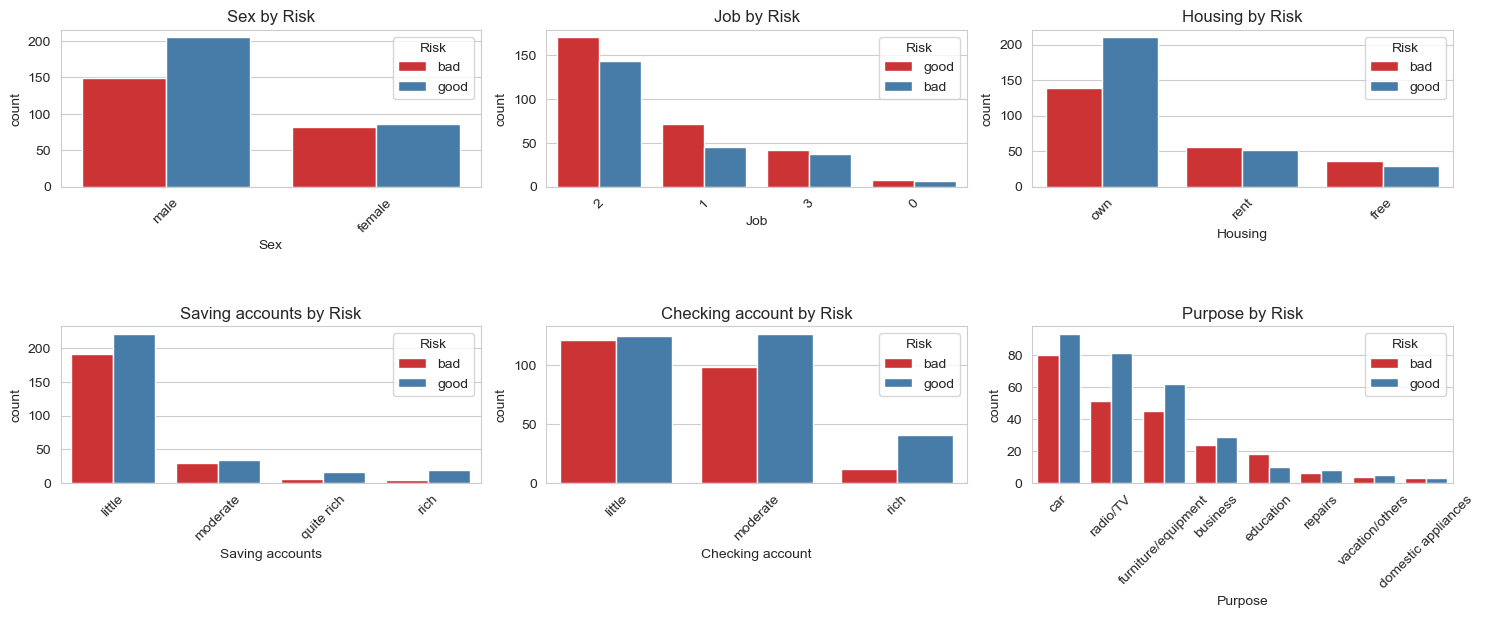

In [61]:
plt.figure(figsize=(15,8))  #Creates a big canvas for multiple plots.

for i, col in enumerate(categorical_cols):     #This loops through each categorical column.
    plt.subplot(3,3,i+1)                       #Creates 9 possible positions (3 rows × 3 columns).
    
    sns.countplot(                               #This shows how many records belong to each category, colored by Risk.
        data=df,
        x=col,
        hue="Risk",
        palette="Set1",
        order=df[col].value_counts().index
    )
    
    plt.title(f"{col} by Risk")              #Improves spacing between charts.
    plt.xticks(rotation=45)                  #Prevents labels from overlapping.

plt.tight_layout()
plt.show()

In [ ]:
#Features Engineering

In [63]:
df.columns 
#This command displays all column names in the dataframe df.

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [64]:
Features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account","Credit amount", "Duration"]
#Here, I create a list of independent variables (input features).

In [65]:
target = "Risk" #Here you define the target variable (output).

In [68]:
df_model = df[Features + [target]].copy() #This line creates a new dataframe for modeling.

In [69]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [70]:
from sklearn.preprocessing import LabelEncoder
import joblib
#This imports LabelEncoder from scikit-learn.It is used to convert categorical data into numbers.

In [71]:
cat_cols = df_model.select_dtypes(include = "object").columns.drop("Risk")
#df_model = your dataset (DataFrame).
#select_dtypes(include="object") = select columns that contain text values.
#.columns = get the column names.
#.drop("Risk") = remove the Risk column from the list.

In [72]:
le_dict = {}
#create an empty dictionary to store the encoders used for each column.

In [75]:
cat_cols
#This simply shows the categorical columns.

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [76]:
for col in cat_cols:                                     #runs the code one column at a time.
    le = LabelEncoder()                                  #A LabelEncoder converts text values into numbers.
    df_model[col] = le.fit_transform(df_model[col])      #fit() --> Learns the unique values.transform() --> Converts them into numbers.
    le_dict[col] = le                                    #Store the encoder for that column in the dictionary.
    joblib.dump(le, f"{col}_encoder.pkl")                #Save the encoder as a file so you can use it later.


In [77]:
le_target = LabelEncoder()    #Create a separate encoder for the target variable.

In [78]:
target  

'Risk'

In [79]:
df_model[target] = le_target.fit_transform(df_model[target])

In [81]:
df_model[target].value_counts()     #1 Good (lower Risk), 0 Bad (Higher Risk), And Count how many times each value appears.

Risk
1    291
0    231
Name: count, dtype: int64

In [82]:
joblib.dump(le_target,"target_encoder.pkl")   #Save the target encoder to a file.

['target_encoder.pkl']

In [84]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [87]:
from sklearn.model_selection import train_test_split
#from → tells Python where to import from.
#sklearn → Machine Learning library (Scikit-learn).
#model_selection → module used for splitting datasets and model evaluation.
#train_test_split → function used to divide data into training and testing datasets.

In [89]:
X = df_model.drop(target, axis = 1)  #axis=1 --> Removes columns axis=0 --> Removes Rows.
#Remove the Risk column from the dataset.
#Store the remaining columns in X.

In [90]:
Y = df_model[target]
#Take the Risk column from the dataset.
#Store it in a new variable called Y.

In [92]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [93]:
Y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int32

In [94]:
target

'Risk'

In [95]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2, stratify = Y, random_state = 1)
#train_test_split() -->This is a function from scikit-learn used to divide data into two parts: Training data → used to train the model,Testing data → used to test the model accuracy.
#X -->contains the input features (independent variables).
#Y -->contains the target variable (what we want to predict).
#X_train -->This is 80% of the feature data used to train the model, The model learns patterns from this data.
#X_test -->This is 20% of the feature data used for testing, This data checks how well the model performs on new data.
#Y_train -->These are the target values corresponding to X_train, Used during model training.
#Y_test -->These are the target values for testing data, Used to compare with model predictions.
#test_size = 0.2 -->20% → Testing data, 80% → Training data.
#stratify = Y -->This keeps the same proportion of classes in training and testing data.
#random_state = 1 -->This ensures the same data split every time you run the code.

In [96]:
X_train.shape

(417, 8)

In [97]:
X_test.shape

(105, 8)

In [101]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#These lines import different tools (models and functions) that you will use to train and evaluate machine learning models.

In [100]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.7 MB/s eta 0:01:01
   ---------------------------------------- 1.0/101.7 MB 1.8 MB/s eta 0:00:56
    --------------------------------------- 1.3/101.7 MB 1.9 MB/s eta 0:00:54
    --------------------------------------- 1.8/101.7 MB 1.8 MB/s eta 0:00:55
    --------------------------------------- 2.1/101.7 MB 1.8 MB/s eta 0:00:56
   - -------------------------------------- 2.6/101.7 MB 1.8 MB/s eta 0:00:55
   - -------------------------------------- 3.1/101.7 MB 1.9 MB/s eta 0:00:53
   - -------------------------------------- 3.4/101.7 MB 1.9 MB/s eta 0:00:53
   - -------------------------------------- 3.9/101.7 MB 1.9 MB/s eta 0:00:53
   - -------------------------------------- 4.2/101.7 MB 1.9 MB/s eta 0:00:53
   - -------------------------------------- 4.7/101.7 MB 1.9 MB/s eta 0:00:53


In [104]:
def train_model(model, param_grid, X_train, Y_train, X_test, Y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, Y_train)
    best_model = grid.best_estimator_
    Y_pred = best_model.predict(X_test)
    acc = accuracy_score(Y_test, Y_pred)
    return best_model, acc, grid.best_params_

#Trains a machine learning model
#Uses GridSearchCV to find the best parameters
#Makes predictions on test data
#Calculates accuracy
#Returns the best model, accuracy, and best parameters

In [107]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")

dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
#dt = DecisionTreeClassifier(random_state=1, class_weight="balanced") -->random_state=1, Ensures the model gives the same result every time you run it.
#class_weight="balanced", Handles imbalanced datasets.


In [108]:
best_dt,acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, Y_train, X_test, Y_test)

In [109]:
print("Decision Tree accuracy", acc_dt)

Decision Tree accuracy 0.580952380952381


In [110]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [113]:
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs = -1)
#This creates a Random Forest Machine Learning Model.
#Random Forest is an ensemble algorithm that uses many decision trees to make predictions.
#Example:
#Imagine 100 trees voting:
#Tree 1 → Good
#Tree 2 → Good
#Tree 3 → Bad
#Tree 4 → Good
#Tree 5 → Good
#Final prediction:
#Majority vote → Good

In [115]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}